In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))  # Graph-SSL
print(sys.path[-1])
from wl_gcl.src.utils.wl_core import WLHierarchyEngine
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx



C:\Users\halac\Graph-SSL


In [6]:
from wl_gcl.src.data_loader.dataset import load_dataset
# 1. Load a molecule
ds_zinc = load_dataset("ZINC", root = "../data")
molecule = ds_zinc.data


--- Molecule Analysis ---
Nodes (Atoms): 29
Edges (Bonds): 32
Average Degree: 2.21


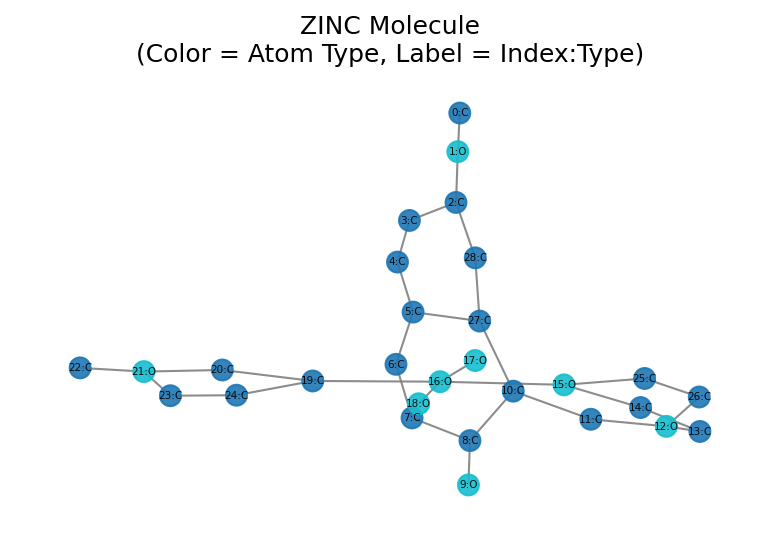

In [49]:
G = to_networkx(molecule, to_undirected=True)

num_nodes = molecule.num_nodes
num_edges = molecule.edge_index.size(1) // 2
avg_degree = (2 * num_edges) / num_nodes

print(f"--- Molecule Analysis ---")
print(f"Nodes (Atoms): {num_nodes}")
print(f"Edges (Bonds): {num_edges}")
print(f"Average Degree: {avg_degree:.2f}")

atom_map = {0: 'C', 1: 'O', 2: 'N', 3: 'F', 4: 'S', 5: 'Cl', 6: 'P', 7: 'Br', 8: 'I'}
node_labels = {i: f"{i}:{atom_map.get(molecule.x[i].item(), '?')}" for i in range(num_nodes)}
plt.figure(figsize=(5, 3))
pos = nx.spring_layout(G, seed=42) 
nx.draw(G, pos, 
        with_labels=True, 
        labels=node_labels,
        node_color=molecule.x.view(-1).numpy(), 
        cmap=plt.cm.tab10, 
        node_size=100, 
        font_size=5,
        edge_color='gray',
        width=1,
        alpha=0.9)

plt.title(f"ZINC Molecule\n(Color = Atom Type, Label = Index:Type)")
plt.show()

Building WL Tree (Convergence Mode: False)...
--- WL Hierarchy Results ---
Number of levels: 4
Number of structural clusters: 66


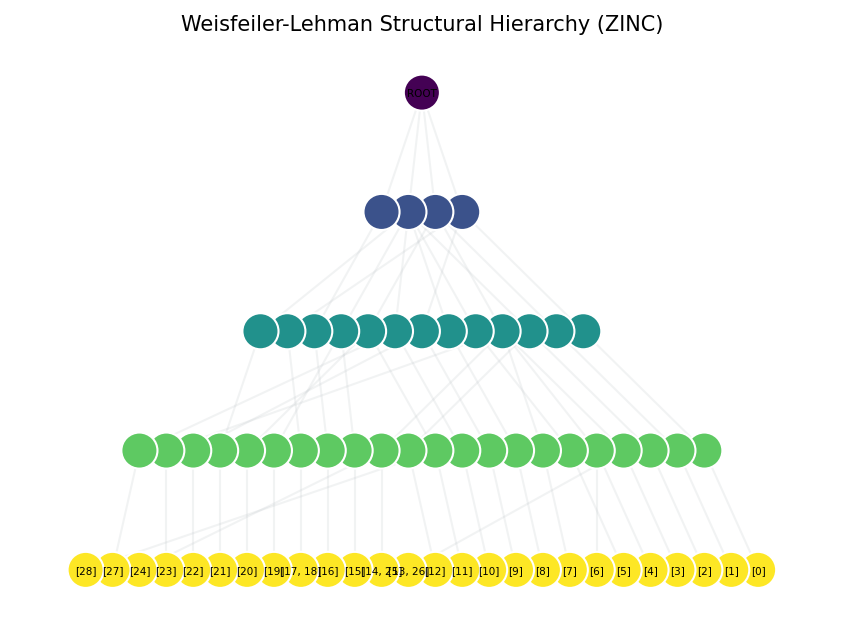

In [40]:
nodes = range(molecule.num_nodes)
edges = molecule.edge_index.t().tolist()

node_features = {i: str(molecule.x[i].item()) for i in nodes}

engine = WLHierarchyEngine(nodes, edges)

engine.build_wl_tree(max_iterations=4)

print(f"--- WL Hierarchy Results ---")
print(f"Number of levels: {max(nx.get_node_attributes(engine._viz_graph, 'subset').values())}")
print(f"Number of structural clusters: {len(engine.tree_members)}")

def visualize_tree(engine):
    plt.figure(figsize=(7, 5), dpi=150)
    
    pos = nx.multipartite_layout(engine._viz_graph, subset_key="subset", align="horizontal")
    for n in pos:
        pos[n] = (pos[n][0], -pos[n][1])
    nx.draw_networkx_edges(engine._viz_graph, pos, alpha=0.2, edge_color='#bdc3c7', arrows=False)

    node_colors = [engine._viz_graph.nodes[n]['subset'] for n in engine._viz_graph.nodes]
    nodes = nx.draw_networkx_nodes(engine._viz_graph, pos, 
                                   node_color=node_colors, 
                                   cmap=plt.cm.viridis, 
                                   node_size=300,
                                   edgecolors='white',
                                   linewidths=1)

    labels = {}
    for n in engine._viz_graph.nodes:
        members = engine.tree_members.get(n, [])
        if engine._viz_graph.out_degree(n) == 0:
            labels[n] = f"{members}"
        elif n == "root":
            labels[n] = "ROOT"

    nx.draw_networkx_labels(engine._viz_graph, pos, labels, font_size=5, font_family='sans-serif')

    plt.title("Weisfeiler-Lehman Structural Hierarchy (ZINC)", fontsize=10)
    plt.axis('off')
    plt.show()

visualize_tree(engine)

In [58]:
target_node = 13
target_type = atom_map.get(molecule.x[target_node].item(), "Unknown")

print(f"Target Node: {target_node} ({target_type})")
print("=" * 30)

for level in range(1, 4):
    # Cluster the node belongs to at this depth
    cluster_id = engine.get_cluster_id(target_node, level)
    cluster_members = engine.get_cluster_at_level(target_node, level)
    
    # Hard Negatives: Nodes that were in the SAME cluster at level t-1, 
    # but are now in a DIFFERENT cluster at level t.
    hard_negatives = engine.get_hard_negatives(target_node, level)
    
    print(f"Level {level}:")
    print(f"  Current Cluster: {cluster_id}")
    print(f"  Cluster Size: {len(cluster_members)}")
    print(f"  New Hard Negatives found: {hard_negatives}")
    
    if hard_negatives:
        neg_types = [atom_map.get(molecule.x[n].item()) for n in hard_negatives]
        print(f"  Negative Types: {neg_types}")
    print("")

path = engine.get_wl_path(target_node)
print(f"Structural Signature Path for Node {target_node}:")
for lvl, cid in path:
    print(f"  T={lvl} -> {cid}")

Target Node: 13 (C)
Level 1:
  Current Cluster: It1_9f348ecd
  Cluster Size: 14
  New Hard Negatives found: [0, 2, 5, 8, 9, 10, 12, 15, 16, 17, 18, 19, 21, 22, 27]
  Negative Types: ['C', 'C', 'C', 'C', 'O', 'C', 'O', 'O', 'O', 'O', 'O', 'C', 'O', 'C', 'C']

Level 2:
  Current Cluster: It2_c7fe1b86
  Cluster Size: 10
  New Hard Negatives found: [1, 11, 20, 28]
  Negative Types: ['O', 'C', 'C', 'C']

Level 3:
  Current Cluster: It3_b553d542
  Cluster Size: 3
  New Hard Negatives found: [4, 6, 7, 14, 23, 24, 25]
  Negative Types: ['C', 'C', 'C', 'C', 'C', 'C', 'C']

Structural Signature Path for Node 13:
  T=0 -> root
  T=1 -> It1_9f348ecd
  T=2 -> It2_c7fe1b86
  T=3 -> It3_b553d542
  T=4 -> It4_330cd647


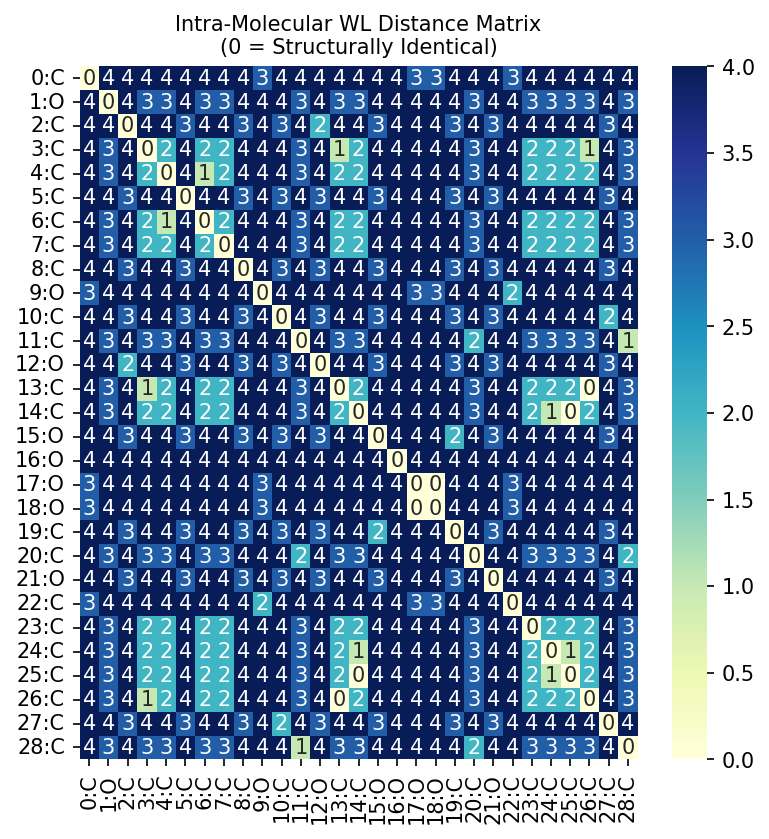

In [55]:
import numpy as np
import seaborn as sns

num_nodes = molecule.num_nodes
dist_matrix = np.zeros((num_nodes, num_nodes))

for i in range(num_nodes):
    for j in range(num_nodes):
        dist_matrix[i, j] = engine.get_wl_distance(i, j)

plt.figure(figsize=(6, 6), dpi=150)
sns.heatmap(dist_matrix, annot=True, cmap="YlGnBu", fmt=".0f", 
            xticklabels=[f"{i}:{atom_map.get(molecule.x[i].item())}" for i in range(num_nodes)],
            yticklabels=[f"{i}:{atom_map.get(molecule.x[i].item())}" for i in range(num_nodes)])

plt.title("Intra-Molecular WL Distance Matrix\n(0 = Structurally Identical)", fontsize=10)
plt.show()


In [63]:
twins_found = False
for i in range(num_nodes):
    # Similar nodes with delta=0 means they share the same leaf in the WL tree
    sim_nodes = engine.get_similar_nodes(i, delta=0)
    if sim_nodes:
        twins_found = True
        print(f"Node {i} ({atom_map.get(molecule.x[i].item())}) is identical to nodes: {sim_nodes}")

if not twins_found:
    print("No structural symmetries found in this specific molecule.")

Node 13 (C) is identical to nodes: [26]
Node 14 (C) is identical to nodes: [25]
Node 17 (O) is identical to nodes: [18]
Node 18 (O) is identical to nodes: [17]
Node 25 (C) is identical to nodes: [14]
Node 26 (C) is identical to nodes: [13]


In [73]:
u, v = 0, 9

path_u = engine.get_wl_cluster_sequence(u)
path_v = engine.get_wl_cluster_sequence(v)

print(f"Comparing Node {u} vs Node {v}")
print("-" * 40)
print(f"{'Level':<8} | {'Node ' + str(u) + ' Cluster':<20} | {'Node ' + str(v) + ' Cluster':<20}")
print("-" * 40)

for level, (c_u, c_v) in enumerate(zip(path_u, path_v)):
    match = "✅ Match" if c_u == c_v else "❌ Diverge"
    print(f"{level:<8} | {c_u:<20} | {c_v:<20} | {match}")

similarity = engine.get_wl_similarity(u, v)
distance = engine.get_wl_distance(u, v)
print(f"\nFinal Normalized Structural Similarity: {similarity:.2%}")
print(f"Distance between the two nodes: {distance}")

Comparing Node 0 vs Node 9
----------------------------------------
Level    | Node 0 Cluster       | Node 9 Cluster      
----------------------------------------
0        | root                 | root                 | ✅ Match
1        | It1_a4a03e33         | It1_a4a03e33         | ✅ Match
2        | It2_b819db98         | It2_28f1a4a5         | ❌ Diverge
3        | It3_1214c8d0         | It3_38fca97d         | ❌ Diverge
4        | It4_8f4dc6d1         | It4_03ce8be8         | ❌ Diverge

Final Normalized Structural Similarity: 25.00%
Distance between the two nodes: 3
